In [ ]:
!pip install gymnasium

In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import torch.distributions as distributions

env = gym.make('Blackjack-v1', natural=False, sab=False)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch import distributions

class ActorCriticFFtoGRU(nn.Module):
    def __init__(self, observation_space_size, action_space_size, hidden_size, layers=1):
        super(ActorCriticFFtoGRU, self).__init__()

        # FF Feature Extractor
        self.feature_extractor = nn.Linear(observation_space_size, hidden_size)

        # RNN (GRU)
        self.gru = nn.GRU(
            hidden_size,
            hidden_size,
            num_layers=layers,
            batch_first=True
        )

        # Final Heads
        self.actor_head = nn.Linear(hidden_size, action_space_size)
        self.critic_head = nn.Linear(hidden_size, 1)

        self.layers = layers
        self.hidden_size = hidden_size

    def forward(self, x, h):
        # x: (batch, obs_size)
        x = F.relu(self.feature_extractor(x))
        x = x.unsqueeze(1)  # (batch, 1, hidden)

        output, h = self.gru(x, h)
        output = output.squeeze(1)

        return self.actor_head(output), self.critic_head(output), h


In [ ]:
def calculate_returns(rewards, gamma):
    returns = []
    G = 0.0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    return torch.tensor(returns, dtype=torch.float32)


In [ ]:
def train_actor_critic(
    env,
    observation_space_size,
    action_space_size,
    lr=1e-3,
    episodes=25_000,
    gamma=0.99,
    hidden=64,
    layers=1
):
    model = ActorCriticFFtoGRU(
        observation_space_size,
        action_space_size,
        hidden_size=hidden,
        layers=layers
    )

    optimizer = optim.Adam(model.parameters(), lr=lr)

    episode_rewards = []
    actor_losses = []
    critic_losses = []

    for episode in range(episodes):
        observation, _ = env.reset()

        # (num_layers, batch, hidden_size)
        h = torch.zeros(layers, 1, hidden)

        log_probs = []
        values = []
        rewards = []

        done = False
        truncated = False
        episode_reward = 0.0

        while not done and not truncated:
            obs_tensor = torch.tensor(
                observation, dtype=torch.float32
            ).unsqueeze(0)

            logits, value, h = model(obs_tensor, h)

            dist = distributions.Categorical(logits=logits)
            action = dist.sample()
            log_prob = dist.log_prob(action)

            next_obs, reward, done, truncated, _ = env.step(action.item())

            log_probs.append(log_prob)
            values.append(value.squeeze())
            rewards.append(reward)

            observation = next_obs
            episode_reward += reward

        # Bootstrap terminal value
        values.append(torch.tensor(0.0))

        returns = calculate_returns(rewards, gamma)
        values_tensor = torch.stack(values)

        advantages = returns - values_tensor[:-1]

        actor_loss = -(torch.stack(log_probs) * advantages.detach()).mean()
        critic_loss = F.mse_loss(values_tensor[:-1], returns.detach())

        total_loss = actor_loss + critic_loss

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        episode_rewards.append(episode_reward)
        actor_losses.append(actor_loss.item())
        critic_losses.append(critic_loss.item())

        if episode % 100 == 0:
            print(
                f"Episode {episode} | "
                f"Reward: {episode_reward:.2f} | "
                f"Actor Loss: {actor_loss.item():.4f} | "
                f"Critic Loss: {critic_loss.item():.4f}"
            )

    return model, episode_rewards, actor_losses, critic_losses



In [ ]:
model, rewards, actor_losses, critic_losses = train_actor_critic(
    env=env,
    observation_space_size=3,
    action_space_size=env.action_space.n,
    lr=0.0005,
    episodes=50000,
    gamma=0.99,
    hidden=128,
    layers=2
)

Episode 0 | Reward: -1.00 | Actor Loss: -0.6543 | Critic Loss: 0.7496
Episode 100 | Reward: -1.00 | Actor Loss: -0.1606 | Critic Loss: 0.6973
Episode 200 | Reward: -1.00 | Actor Loss: -0.1459 | Critic Loss: 0.5576
Episode 300 | Reward: 0.00 | Actor Loss: 0.0057 | Critic Loss: 0.0088
Episode 400 | Reward: 1.00 | Actor Loss: 0.0257 | Critic Loss: 0.9207
Episode 500 | Reward: -1.00 | Actor Loss: -0.0272 | Critic Loss: 0.7618
Episode 600 | Reward: 1.00 | Actor Loss: 0.0114 | Critic Loss: 0.8104
Episode 700 | Reward: -1.00 | Actor Loss: -0.0170 | Critic Loss: 1.4896
Episode 800 | Reward: 1.00 | Actor Loss: 0.0191 | Critic Loss: 1.1001
Episode 900 | Reward: -1.00 | Actor Loss: -0.0050 | Critic Loss: 0.4661
Episode 1000 | Reward: -1.00 | Actor Loss: -0.0058 | Critic Loss: 1.0531
Episode 1100 | Reward: -1.00 | Actor Loss: -0.0056 | Critic Loss: 1.0738
Episode 1200 | Reward: -1.00 | Actor Loss: -0.0083 | Critic Loss: 0.6393
Episode 1300 | Reward: 1.00 | Actor Loss: 0.0154 | Critic Loss: 2.2143


In [ ]:
import numpy as np
import torch

def evaluate_agent(
    model,
    env,
    num_test_episodes=10_000,
    device="cpu",
    layers=1,
    hidden=64
):
    model.eval()
    model.to(device)

    total_rewards = []
    wins = 0

    with torch.no_grad():
        for episode in range(num_test_episodes):
            observation, _ = env.reset()
            episode_reward = 0
            done = False
            truncated = False

            # Reset hidden state for each episode
            h = torch.zeros(layers, 1, hidden, device=device)

            while not (done or truncated):
                obs_tensor = torch.tensor(
                    observation, dtype=torch.float32
                ).unsqueeze(0).to(device)

                # Forward pass with hidden state
                action_logits, _, h = model(obs_tensor, h)

                # Greedy action selection
                action = torch.argmax(action_logits, dim=1).item()

                observation, reward, done, truncated, _ = env.step(action)
                episode_reward += reward

            total_rewards.append(episode_reward)
            if episode_reward > 0:
                wins += 1

    avg_reward = np.mean(total_rewards)
    win_rate = wins / num_test_episodes

    print(f"\nEvaluation over {num_test_episodes} episodes:")
    print(f"Average Reward: {avg_reward:.4f}")
    print(f"Win Rate: {win_rate * 100:.2f}%")

    return avg_reward, win_rate


In [ ]:
configs = [
    {
        "name": "Shallow (1 Layer) gamma 0.99 and 128 hidden layers",
        "lr": 0.0005, "episodes": 10000, "gamma": 0.99,
        "hidden": 128, "layers": 1
    },
    {
        "name": "Deep (2 Layers) gamma 0.99 and 128 hidden layers",
        "lr": 0.0005, "episodes": 10000, "gamma": 0.99,
        "hidden": 128, "layers": 2
    },
    {
        "name": "Shallow (1 Layers) with gamma 0.99 and 128 hidden layers",
        "lr": 0.0005, "episodes": 10000, "gamma": 0.95,
        "hidden": 128, "layers": 1
    },
    {
        "name": "Shallow (1 Layers) with gamma 0.99 and 256 hidden layers",
        "lr": 0.0005, "episodes": 10000, "gamma": 0.99,
        "hidden": 256, "layers": 1
    },
    {
        "name": "Shallow (1 Layers) with gamma 0.99 and 512 hidden layers",
        "lr": 0.0005, "episodes": 10000, "gamma": 0.99,
        "hidden": 512, "layers": 1
    },
    {
        "name": "Shallow (1 Layers) with gamma 0.99 and 512 hidden layers and greater learning rate",
        "lr": 0.001, "episodes": 10000, "gamma": 0.99,
        "hidden": 512, "layers": 1
    },

]

In [ ]:
def run_experiments(
    env,
    configs,
    observation_space_size,
    action_space_size,
    eval_episodes=10_000,
    device="cpu"
):
    results = []

    for cfg in configs:
        print("\n" + "=" * 80)
        print(f"Running experiment: {cfg['name']}")
        print("=" * 80)

        # ------------------
        # Train
        # ------------------
        model, train_rewards, actor_losses, critic_losses = train_actor_critic(
            env=env,
            observation_space_size=observation_space_size,
            action_space_size=action_space_size,
            lr=cfg["lr"],
            episodes=cfg["episodes"],
            gamma=cfg["gamma"],
            hidden=cfg["hidden"],
            layers=cfg["layers"],
        )

        model.to(device)
        model.eval()

        # ------------------
        # Evaluate (GRU-aware)
        # ------------------
        total_reward = 0.0
        wins = 0

        with torch.no_grad():
            for _ in range(eval_episodes):
                observation, _ = env.reset()

                # Reset GRU hidden state per episode
                h = torch.zeros(cfg["layers"], 1, cfg["hidden"], device=device)

                done = False
                truncated = False
                episode_reward = 0.0

                while not done and not truncated:
                    obs_tensor = torch.tensor(
                        observation, dtype=torch.float32, device=device
                    ).unsqueeze(0)

                    logits, _, h = model(obs_tensor, h)
                    action = torch.argmax(logits, dim=-1).item()

                    observation, reward, done, truncated, _ = env.step(action)
                    episode_reward += reward

                total_reward += episode_reward
                if episode_reward > 0:
                    wins += 1

        avg_reward = total_reward / eval_episodes
        win_rate = wins / eval_episodes

        results.append({
            "name": cfg["name"],
            "lr": cfg["lr"],
            "episodes": cfg["episodes"],
            "gamma": cfg["gamma"],
            "hidden": cfg["hidden"],
            "layers": cfg["layers"],
            "avg_reward": avg_reward,
            "win_rate": win_rate,
        })

    return results


In [ ]:
results = run_experiments(
    env=env,
    configs=configs,
    observation_space_size=3,
    action_space_size=env.action_space.n,
    eval_episodes=10000,
    device="cpu",
)


Running experiment: Shallow (1 Layer) gamma 0.99 and 128 hidden layers
Episode 0 | Reward: -1.00 | Actor Loss: -0.3521 | Critic Loss: 0.6597
Episode 100 | Reward: -1.00 | Actor Loss: 0.0082 | Critic Loss: 0.0025
Episode 200 | Reward: -1.00 | Actor Loss: -0.0354 | Critic Loss: 0.8554
Episode 300 | Reward: -1.00 | Actor Loss: -0.0127 | Critic Loss: 0.8337
Episode 400 | Reward: 1.00 | Actor Loss: 0.0189 | Critic Loss: 1.0349
Episode 500 | Reward: -1.00 | Actor Loss: -0.0049 | Critic Loss: 0.2187
Episode 600 | Reward: -1.00 | Actor Loss: -0.0125 | Critic Loss: 1.3982
Episode 700 | Reward: -1.00 | Actor Loss: -0.0251 | Critic Loss: 1.7292
Episode 800 | Reward: 1.00 | Actor Loss: 1.0589 | Critic Loss: 0.2461
Episode 900 | Reward: -1.00 | Actor Loss: -0.0248 | Critic Loss: 1.0448
Episode 1000 | Reward: 1.00 | Actor Loss: 0.0166 | Critic Loss: 0.7469
Episode 1100 | Reward: 1.00 | Actor Loss: 0.0075 | Critic Loss: 0.9564
Episode 1200 | Reward: 1.00 | Actor Loss: 0.0062 | Critic Loss: 0.7564
Ep

In [ ]:
import matplotlib.pyplot as plt

def plot_experiment_results(results, sort_by="win_rate"):
    results = sorted(results, key=lambda x: x[sort_by], reverse=True)

    names = [r["name"] for r in results]
    avg_rewards = [r["avg_reward"] for r in results]
    win_rates = [r["win_rate"] for r in results]

    # --- Average Reward ---
    plt.figure(figsize=(10, 6))
    plt.barh(names, avg_rewards)
    plt.xlabel("Average Reward")
    plt.title("Average Reward per Configuration")
    for i, v in enumerate(avg_rewards):
        plt.text(v, i, f"{v:.3f}", va="center")
    plt.tight_layout()
    plt.show()

    # --- Win Rate ---
    plt.figure(figsize=(10, 6))
    plt.barh(names, win_rates)
    plt.xlabel("Win Rate")
    plt.title("Win Rate per Configuration")
    for i, v in enumerate(win_rates):
        plt.text(v, i, f"{v*100:.2f}%", va="center")
    plt.tight_layout()
    plt.show()

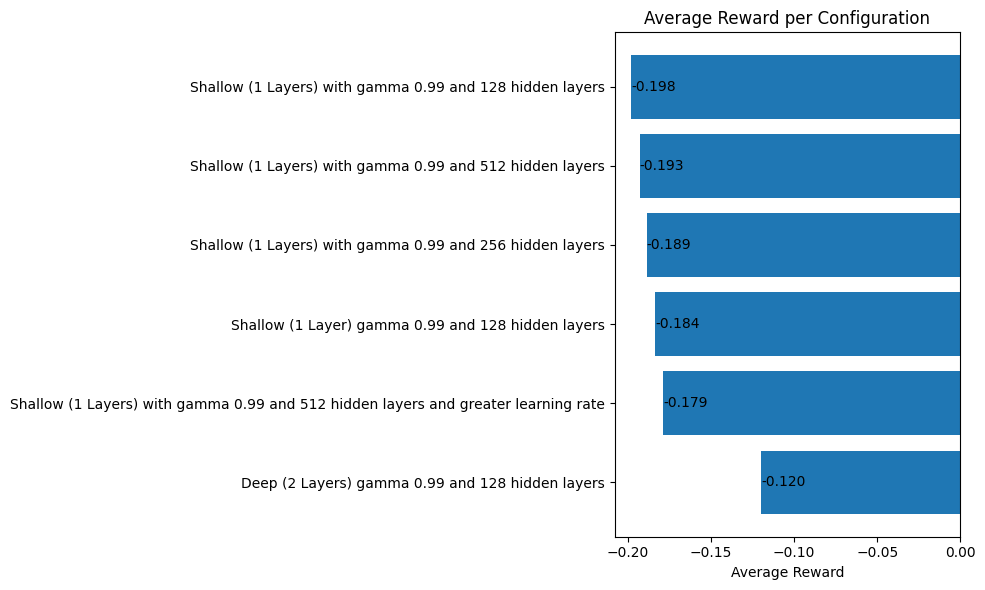

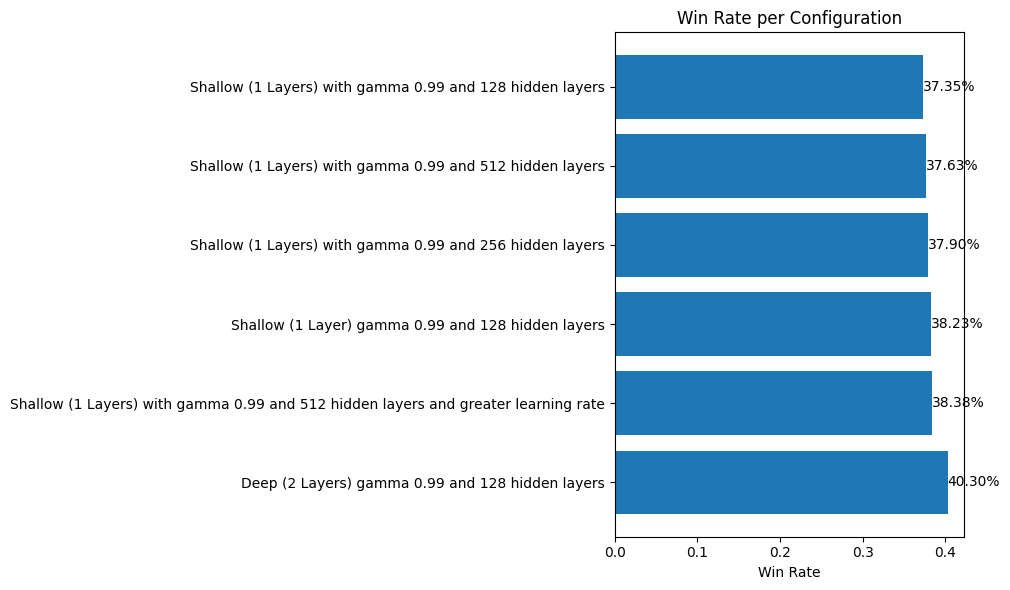

In [ ]:
plot_experiment_results(results)

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 13.3 MB/s eta 0:00:00


In [ ]:
import optuna

def objective(trial):
    # --- Hyperparameters to tune ---
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    hidden = trial.suggest_categorical("hidden", [32, 64, 128, 256, 512])
    layers = trial.suggest_int("layers", 1, 3)
    gamma = trial.suggest_float("gamma", 0.9, 0.999)

    # --- Training / Evaluation budgets ---
    train_episodes = 20_000   # smaller for tuning
    eval_episodes = 1_000

    # --- Train model ---
    model, _, _, _ = train_actor_critic(
        env=env,
        observation_space_size=3,
        action_space_size=env.action_space.n,
        lr=lr,
        episodes=train_episodes,
        gamma=gamma,
        hidden=hidden,
        layers=layers,
    )

    # --- Evaluate ---
    avg_reward, win_rate = evaluate_agent(
        model=model,
        env=env,
        num_test_episodes=eval_episodes,
        device="cpu",
        layers=layers,
        hidden=hidden
    )

    # --- Objective to maximize ---
    return win_rate

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Best trial:")
print(study.best_trial)


[I 2026-01-22 17:38:46,754] A new study created in memory with name: no-name-21669597-0716-43c6-8e9d-b700d8bee7c2


Episode 0 | Reward: 1.00 | Actor Loss: 0.6931 | Critic Loss: 0.9952
Episode 100 | Reward: 1.00 | Actor Loss: 0.0501 | Critic Loss: 1.5353
Episode 200 | Reward: 1.00 | Actor Loss: 0.0238 | Critic Loss: 1.8304
Episode 300 | Reward: -1.00 | Actor Loss: -0.0035 | Critic Loss: 0.3174
Episode 400 | Reward: 1.00 | Actor Loss: 0.0099 | Critic Loss: 2.3594
Episode 500 | Reward: 1.00 | Actor Loss: 0.0086 | Critic Loss: 1.8010
Episode 600 | Reward: -1.00 | Actor Loss: -0.0071 | Critic Loss: 0.8924
Episode 700 | Reward: -1.00 | Actor Loss: -0.0076 | Critic Loss: 1.0753
Episode 800 | Reward: -1.00 | Actor Loss: -0.0013 | Critic Loss: 0.5610
Episode 900 | Reward: -1.00 | Actor Loss: -0.0014 | Critic Loss: 0.6643
Episode 1000 | Reward: -1.00 | Actor Loss: -0.0016 | Critic Loss: 0.8063
Episode 1100 | Reward: -1.00 | Actor Loss: -0.0273 | Critic Loss: 0.4815
Episode 1200 | Reward: 1.00 | Actor Loss: 0.0059 | Critic Loss: 0.7423
Episode 1300 | Reward: 1.00 | Actor Loss: 0.0068 | Critic Loss: 0.9574
Epis

[I 2026-01-22 18:11:00,499] Trial 0 finished with value: 0.378 and parameters: {'lr': 0.004992501412882072, 'hidden': 512, 'layers': 3, 'gamma': 0.9912911402306854}. Best is trial 0 with value: 0.378.



Evaluation over 1000 episodes:
Average Reward: -0.1860
Win Rate: 37.80%
Episode 0 | Reward: 1.00 | Actor Loss: 0.6457 | Critic Loss: 0.9051
Episode 100 | Reward: -1.00 | Actor Loss: -0.5185 | Critic Loss: 0.5946
Episode 200 | Reward: 1.00 | Actor Loss: 0.8367 | Critic Loss: 1.4715
Episode 300 | Reward: -1.00 | Actor Loss: -0.4533 | Critic Loss: 0.3359
Episode 400 | Reward: -1.00 | Actor Loss: -0.3976 | Critic Loss: 0.5143
Episode 500 | Reward: -1.00 | Actor Loss: -0.3678 | Critic Loss: 0.5350
Episode 600 | Reward: -1.00 | Actor Loss: -0.2988 | Critic Loss: 0.5797
Episode 700 | Reward: 1.00 | Actor Loss: 0.3706 | Critic Loss: 1.4856
Episode 800 | Reward: -1.00 | Actor Loss: -0.3662 | Critic Loss: 0.3799
Episode 900 | Reward: -1.00 | Actor Loss: -0.3462 | Critic Loss: 0.5188
Episode 1000 | Reward: 0.00 | Actor Loss: 0.0456 | Critic Loss: 0.0466
Episode 1100 | Reward: 1.00 | Actor Loss: 0.2353 | Critic Loss: 1.4196
Episode 1200 | Reward: 1.00 | Actor Loss: 0.2121 | Critic Loss: 1.3090
Ep

[I 2026-01-22 18:12:46,156] Trial 1 finished with value: 0.401 and parameters: {'lr': 0.00014234379231913474, 'hidden': 32, 'layers': 3, 'gamma': 0.9177534050549478}. Best is trial 1 with value: 0.401.


...


Evaluation over 1000 episodes:
Average Reward: -0.1850
Win Rate: 38.20%
Episode 0 | Reward: -1.00 | Actor Loss: -0.7438 | Critic Loss: 0.8899
Episode 100 | Reward: 1.00 | Actor Loss: 0.2288 | Critic Loss: 0.9389
Episode 200 | Reward: -1.00 | Actor Loss: -0.0187 | Critic Loss: 0.3278
Episode 300 | Reward: -1.00 | Actor Loss: -3.9061 | Critic Loss: 0.9983
Episode 400 | Reward: -1.00 | Actor Loss: -0.0261 | Critic Loss: 0.7044
Episode 500 | Reward: -1.00 | Actor Loss: -0.0150 | Critic Loss: 0.8863
Episode 600 | Reward: -1.00 | Actor Loss: -0.0081 | Critic Loss: 1.1117
Episode 700 | Reward: 1.00 | Actor Loss: 0.0113 | Critic Loss: 1.3102
Episode 800 | Reward: -1.00 | Actor Loss: -0.0054 | Critic Loss: 1.0963
Episode 900 | Reward: -1.00 | Actor Loss: -0.0082 | Critic Loss: 0.3586
Episode 1000 | Reward: 1.00 | Actor Loss: 0.0156 | Critic Loss: 2.1128
Episode 1100 | Reward: -1.00 | Actor Loss: -0.0112 | Critic Loss: 0.9720
Episode 1200 | Reward: -1.00 | Actor Loss: -0.0123 | Critic Loss: 1.2

[I 2026-01-22 19:35:54,488] Trial 28 finished with value: 0.393 and parameters: {'lr': 0.0008220688374250813, 'hidden': 64, 'layers': 3, 'gamma': 0.9453514141040799}. Best is trial 17 with value: 0.428.



Evaluation over 1000 episodes:
Average Reward: -0.1700
Win Rate: 39.30%
Episode 0 | Reward: -1.00 | Actor Loss: -0.7228 | Critic Loss: 1.0919
Episode 100 | Reward: -1.00 | Actor Loss: -0.0688 | Critic Loss: 0.7369
Episode 200 | Reward: 1.00 | Actor Loss: 0.0217 | Critic Loss: 1.8407
Episode 300 | Reward: 1.00 | Actor Loss: 0.0839 | Critic Loss: 2.2365
Episode 400 | Reward: -1.00 | Actor Loss: -0.0007 | Critic Loss: 0.4370
Episode 500 | Reward: -1.00 | Actor Loss: -0.0006 | Critic Loss: 0.8857
Episode 600 | Reward: 1.00 | Actor Loss: 0.0007 | Critic Loss: 2.0138
Episode 700 | Reward: -1.00 | Actor Loss: -0.0003 | Critic Loss: 0.7599
Episode 800 | Reward: -1.00 | Actor Loss: -0.0000 | Critic Loss: 0.6304
Episode 900 | Reward: 1.00 | Actor Loss: 0.0002 | Critic Loss: 1.9078
Episode 1000 | Reward: 1.00 | Actor Loss: 0.0005 | Critic Loss: 0.9636
Episode 1100 | Reward: -1.00 | Actor Loss: -0.0011 | Critic Loss: 0.6996
Episode 1200 | Reward: -1.00 | Actor Loss: -0.0084 | Critic Loss: 1.0382


[I 2026-01-22 19:59:52,962] Trial 29 finished with value: 0.413 and parameters: {'lr': 0.0004186653100060106, 'hidden': 512, 'layers': 3, 'gamma': 0.9744697062133775}. Best is trial 17 with value: 0.428.



Evaluation over 1000 episodes:
Average Reward: -0.1230
Win Rate: 41.30%
Best trial:
FrozenTrial(number=17, state=<TrialState.COMPLETE: 1>, values=[0.428], datetime_start=datetime.datetime(2026, 1, 22, 18, 53, 42, 624585), datetime_complete=datetime.datetime(2026, 1, 22, 18, 55, 33, 444251), params={'lr': 0.0006520999960677444, 'hidden': 64, 'layers': 3, 'gamma': 0.9783614662439232}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'lr': FloatDistribution(high=0.01, log=True, low=0.0001, step=None), 'hidden': CategoricalDistribution(choices=(32, 64, 128, 256, 512)), 'layers': IntDistribution(high=3, log=False, low=1, step=1), 'gamma': FloatDistribution(high=0.999, log=False, low=0.9, step=None)}, trial_id=17, value=None)


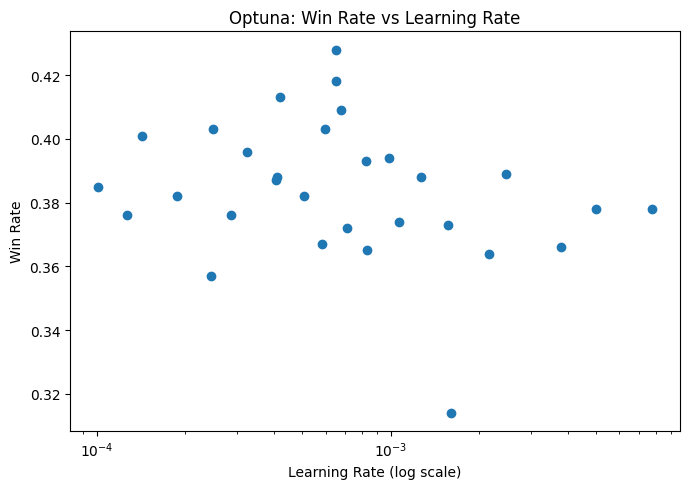

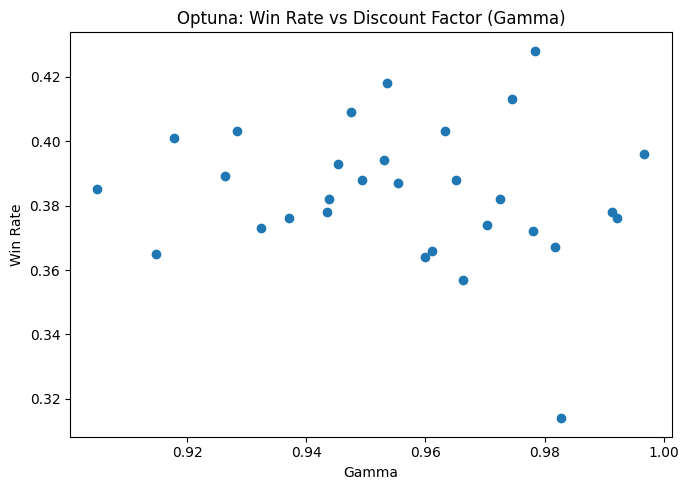

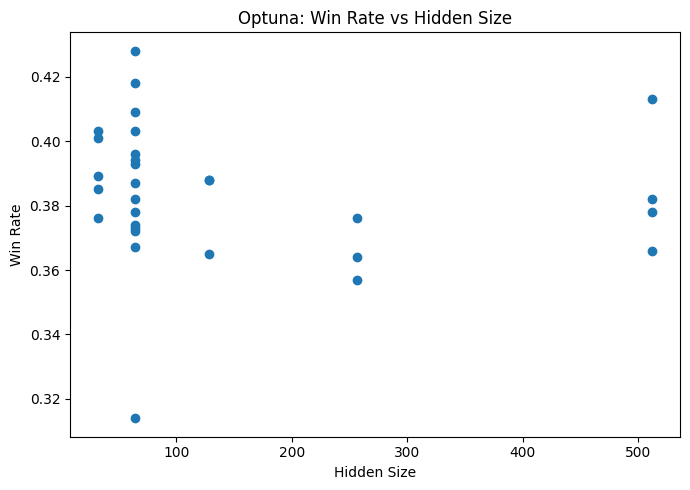

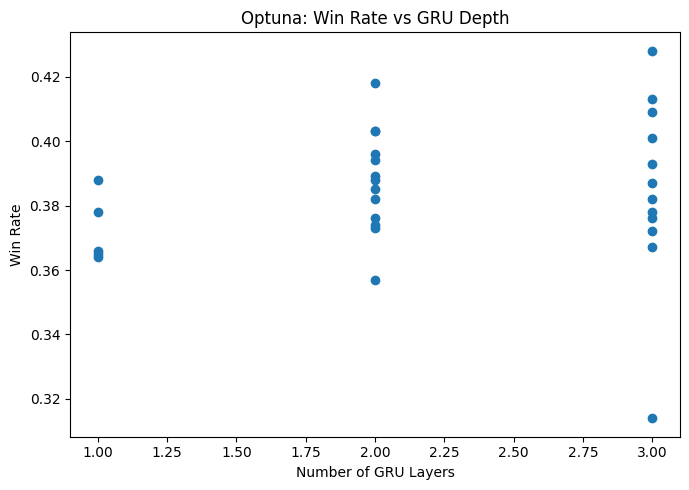

In [ ]:
import matplotlib.pyplot as plt

# Extract completed trials
trials = [t for t in study.trials if t.value is not None]

# Objective values
win_rates = [t.value for t in trials]

# Hyperparameters
lrs = [t.params["lr"] for t in trials]
gammas = [t.params["gamma"] for t in trials]
hidden_sizes = [t.params["hidden"] for t in trials]
num_layers = [t.params["layers"] for t in trials]

# --- Win Rate vs Learning Rate ---
plt.figure(figsize=(7, 5))
plt.scatter(lrs, win_rates)
plt.xscale("log")
plt.xlabel("Learning Rate (log scale)")
plt.ylabel("Win Rate")
plt.title("Optuna: Win Rate vs Learning Rate")
plt.tight_layout()
plt.show()

# --- Win Rate vs Gamma ---
plt.figure(figsize=(7, 5))
plt.scatter(gammas, win_rates)
plt.xlabel("Gamma")
plt.ylabel("Win Rate")
plt.title("Optuna: Win Rate vs Discount Factor (Gamma)")
plt.tight_layout()
plt.show()

# --- Win Rate vs Hidden Size ---
plt.figure(figsize=(7, 5))
plt.scatter(hidden_sizes, win_rates)
plt.xlabel("Hidden Size")
plt.ylabel("Win Rate")
plt.title("Optuna: Win Rate vs Hidden Size")
plt.tight_layout()
plt.show()

# --- Win Rate vs GRU Layers ---
plt.figure(figsize=(7, 5))
plt.scatter(num_layers, win_rates)
plt.xlabel("Number of GRU Layers")
plt.ylabel("Win Rate")
plt.title("Optuna: Win Rate vs GRU Depth")
plt.tight_layout()
plt.show()


In [ ]:
best = study.best_trial

print("\nBest Trial Summary")
print("------------------")
print(f"Win Rate: {best.value:.4f}")
for k, v in best.params.items():
    print(f"{k}: {v}")


Best Trial Summary
------------------
Win Rate: 0.4280
lr: 0.0006520999960677444
hidden: 64
layers: 3
gamma: 0.9783614662439232


In [ ]:
best = study.best_trial

print("\nBest Trial Summary")
print("------------------")
print(f"Win Rate: {best.value:.4f}")
for k, v in best.params.items():
    print(f"{k}: {v}")


Best Trial Summary
------------------
Win Rate: 0.4280
lr: 0.0006520999960677444
hidden: 64
layers: 3
gamma: 0.9783614662439232
